In [ ]:
import pandas as pd
import numpy as np
import json
import glob
import re
import statsmodels.genmod.bayes_mixed_glm as bmg
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ------------------------------------------------------------
# 1. Load & parse
# ------------------------------------------------------------
file_list = glob.glob('*.json')
all_data = []
for file in file_list:
    with open(file, 'r', encoding='utf-8') as f:
        data = json.load(f)
        all_data.extend(data if isinstance(data, list) else [data])

df = pd.DataFrame(all_data)

def extract_decision(text):
    if not isinstance(text, str):
        return np.nan
    m = re.search(r"DECISION:\s*(SWITCH|NO_SWITCH|NO SWITCH|STAY)", text.upper())
    if not m:
        return np.nan
    d = m.group(1).replace(" ", "_")
    return "NO_SWITCH" if d == "STAY" else d

df['decision_val'] = df['content'].apply(
    lambda x: 1.0 if extract_decision(x) == "SWITCH" else
              (0.0 if extract_decision(x) == "NO_SWITCH" else np.nan)
)
df = df[df['decision_val'].notna()].copy()
df['decision_val'] = df['decision_val'].astype(float)

# ------------------------------------------------------------
# 2. Set baseline
# ------------------------------------------------------------
RESP_COL = 'responsibility' if 'responsibility' in df.columns else 'responsibility_name'

df[RESP_COL] = pd.Categorical(
    df[RESP_COL],
    categories=['neutral', 'not_responsible', 'responsible'],
    ordered=False
)
df['role'] = pd.Categorical(
    df['role'],
    categories=['role_A', 'role_B', 'role_C', 'role_D', 'role_E', 'role_F', 'role_G'],
    ordered=False
)
df['model'] = df['model'].astype(str)

print(f"Valid rows: {len(df)}")
print(f"{RESP_COL} levels: {df[RESP_COL].cat.categories.tolist()}")
print(f"role levels:        {df['role'].cat.categories.tolist()}")
print(f"model values:       {df['model'].unique()}")

# ------------------------------------------------------------
# 3. Fit Logistic GLMM
#    Fixed:  responsibility * role (main effects + interactions)
#    Random: (1 | model)
# ------------------------------------------------------------
formula = (
    f"decision_val ~ "
    f"C({RESP_COL}, Treatment('neutral')) * C(role, Treatment('role_A'))"
)

# Random effect: model random intercept
random_effects = {"model": "0 + C(model)"}

model = bmg.BinomialBayesMixedGLM.from_formula(
    formula,
    random_effects,
    data=df
)

result = model.fit_map()
print(result.summary())

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import re
from scipy import stats

# --- Extract Post.Mean and Post.SD directly from summary table ---
# params has extra random-effect predictions beyond fep+vcp; slice to match summary
names = result.model.fep_names + result.model.vcp_names
n_params = len(names)
means = result.params[:n_params]

# Parse Post.SD from summary (robust across statsmodels versions)
_sds = []
for line in result.summary().as_text().split('\n'):
    m = re.search(r'\s+[MV]\s+([-\d.]+)\s+([\d.]+)', line)
    if m:
        _sds.append(float(m.group(2)))
sds = np.array(_sds)
assert len(sds) == len(means), f'SD parse mismatch: {len(sds)} vs {len(means)}'


def clean_name(n):
    n = n.replace("C(responsibility, Treatment('neutral'))", 'resp')
    n = n.replace("C(role, Treatment('role_A'))", 'role')
    n = n.replace('[T.', '[')
    return n

clean_names = [clean_name(n) for n in names]
fixed_idx       = list(range(len(result.model.fep_names)))
variance_idx    = list(range(len(result.model.fep_names), len(names)))
intercept_idx   = [i for i in fixed_idx if 'resp' not in clean_names[i] and 'role' not in clean_names[i]]
resp_main_idx   = [i for i in fixed_idx if 'resp[' in clean_names[i] and ':' not in clean_names[i]]
role_main_idx   = [i for i in fixed_idx if 'role[' in clean_names[i] and ':' not in clean_names[i]]
interaction_idx = [i for i in fixed_idx if ':' in clean_names[i]]

groups = [
    ('Intercept',                intercept_idx,   '#5b7fba'),
    ('Responsibility (main)',    resp_main_idx,   '#e07b3a'),
    ('Role (main)',              role_main_idx,   '#57a86b'),
    ('Resp x Role (interaction)', interaction_idx, '#9b59b6'),
    ('Variance (log SD)',        variance_idx,    '#c0392b'),
]
plot_groups = [(lbl, idx, col) for lbl, idx, col in groups if len(idx) > 0]

fig = plt.figure(figsize=(22, 10))
fig.patch.set_facecolor('white')
fig.suptitle('Posterior Distributions - BinomialBayesMixedGLM (fit_map)\n'
             'Curve = N(Post.Mean, Post.SD) | line = mean | bar = 95% CI | red dashed = 0',
             fontsize=12, fontweight='bold')

width_ratios = [max(1, len(g[1])) for g in plot_groups]
axes_list = fig.subplots(1, len(plot_groups),
                         gridspec_kw={'width_ratios': width_ratios, 'wspace': 0.05})
if len(plot_groups) == 1:
    axes_list = [axes_list]

for ax, (group_label, idxs, color) in zip(axes_list, plot_groups):
    ax.set_facecolor('white')
    all_vals = [v for idx in idxs for v in [means[idx]-3.5*sds[idx], means[idx]+3.5*sds[idx]]]
    y_min, y_max = min(all_vals), max(all_vals)
    pad = (y_max - y_min) * 0.10
    ax.set_ylim(y_min - pad, y_max + pad)

    for i, idx in enumerate(idxs):
        mu, sig = means[idx], sds[idx]
        x = np.linspace(mu - 3.8*sig, mu + 3.8*sig, 300)
        y_pdf = stats.norm.pdf(x, mu, sig)
        y_norm = y_pdf / y_pdf.max() * 0.80
        ax.fill_betweenx(x, i, i + y_norm, alpha=0.50, color=color)
        ax.plot(i + y_norm, x, color=color, lw=1.2)
        ci_lo, ci_hi = mu - 1.96*sig, mu + 1.96*sig
        ax.plot([i+0.05, i+0.75], [mu, mu], color='#111111', lw=1.8, zorder=4)
        ax.plot([i+0.15, i+0.15], [ci_lo, ci_hi], color='#555555', lw=1.2, zorder=3)
        if idx in fixed_idx:
            ax.axhline(0, color='red', lw=0.7, linestyle='--', alpha=0.45)
        lbl = clean_names[idx]
        if ':' in lbl:
            p = lbl.split(':')
            lbl = p[0].split('[')[-1].rstrip(']') + 'x' + p[1].split('[')[-1].rstrip(']')
        elif '[' in lbl:
            lbl = lbl.split('[')[-1].rstrip(']')
        ax.text(i+0.40, y_min - pad*0.5, lbl, ha='center', va='top', fontsize=7.5, color='#333333')

    ax.set_xticks([])
    ax.set_title(group_label, fontsize=10, fontweight='bold', color=color, pad=8)
    ax.spines[['top','right','bottom']].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.yaxis.grid(True, color='#eeeeee', linewidth=0.5)
    ax.set_axisbelow(True)
    ax.set_xlim(-0.1, len(idxs))

axes_list[0].set_ylabel('Parameter Value (log-odds)', fontsize=10)
plt.tight_layout()
plt.savefig('posterior_distributions.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved -> posterior_distributions.png')


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Predicted probabilities & residuals ──
p_hat    = result.predict()                              # Predicted P(SWITCH)
y        = df["decision_val"].values
raw_res  = y - p_hat                                     # Raw residuals
pearson  = raw_res / np.sqrt(p_hat * (1 - p_hat) + 1e-8) # Pearson residuals

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Residual Diagnostics — BinomialBayesMixedGLM (fit_map)",
             fontsize=13, fontweight="bold")

# ── 1. Pearson residuals vs fitted probabilities ──
ax = axes[0, 0]
ax.scatter(p_hat, pearson, alpha=0.15, s=8, color="#4e8dcd")
ax.axhline(0, color="red", lw=1.2, linestyle="--")
ax.set_xlabel("Fitted P(SWITCH)", fontsize=10)
ax.set_ylabel("Pearson Residual", fontsize=10)
ax.set_title("Pearson Residuals vs Fitted", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)

# ── 2. Pearson residual distribution ──
ax = axes[0, 1]
ax.hist(pearson, bins=40, color="#4e8dcd", edgecolor="white", alpha=0.85)
ax.axvline(0, color="red", lw=1.2, linestyle="--")
ax.set_xlabel("Pearson Residual", fontsize=10)
ax.set_ylabel("Count", fontsize=10)
ax.set_title("Distribution of Pearson Residuals", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)

# ── 3. Mean residual by role ──
ax = axes[1, 0]
roles = df["role"].cat.categories.tolist()
means = [raw_res[df["role"] == r].mean() for r in roles]
colors_role = ["#c0392b" if abs(m) > 0.05 else "#7f8c8d" for m in means]
ax.bar(roles, means, color=colors_role, edgecolor="white")
ax.axhline(0, color="black", lw=1.0, linestyle="--")
ax.set_xlabel("Role", fontsize=10)
ax.set_ylabel("Mean Raw Residual", fontsize=10)
ax.set_title("Mean Residual by Role", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", rotation=30)

# ── 4. Mean residual by responsibility ──
ax = axes[1, 1]
resps = df[RESP_COL].cat.categories.tolist()
means_r = [raw_res[df[RESP_COL] == r].mean() for r in resps]
colors_resp = ["#e07b3a" if abs(m) > 0.05 else "#7f8c8d" for m in means_r]
ax.bar(resps, means_r, color=colors_resp, edgecolor="white")
ax.axhline(0, color="black", lw=1.0, linestyle="--")
ax.set_xlabel("Responsibility", fontsize=10)
ax.set_ylabel("Mean Raw Residual", fontsize=10)
ax.set_title("Mean Residual by Responsibility", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("residuals_bayesglmm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → residuals_bayesglmm.png")

# ── Summary statistics ──
print(f"\nPearson residuals  mean={pearson.mean():.4f}  std={pearson.std():.4f}"
      f"  |>2| rate={( np.abs(pearson) > 2).mean():.3f}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.genmod.bayes_mixed_glm as bmg

# ============================================================
# Diagnostics: find worst-fitting cells
# ============================================================
p_hat   = result.predict()
y       = df["decision_val"].values
raw_res = y - p_hat

df_diag = df[["role", RESP_COL, "model"]].copy()
df_diag["p_hat"]   = p_hat
df_diag["raw_res"] = raw_res

worst = (df_diag.groupby(["role", RESP_COL, "model"])
         .agg(mean_res=("raw_res","mean"), p_hat=("p_hat","first"), n=("raw_res","count"))
         .reset_index()
         .assign(abs_res=lambda d: d["mean_res"].abs())
         .sort_values("abs_res", ascending=False))
print("=== Top 10 cells by residual magnitude ===")
print(worst.head(10).to_string(index=False))

# ============================================================
# Optimization: add dilemma random effect (if column exists)
# ============================================================
has_dilemma = "dilemma" in df.columns
print(f"\n'dilemma' column exists: {has_dilemma}")
if has_dilemma:
    print(f"dilemma unique values: {df['dilemma'].nunique()}")

re_opt = {"model": "0 + C(model)"}
if has_dilemma:
    re_opt["dilemma"] = "0 + C(dilemma)"

model_opt = bmg.BinomialBayesMixedGLM.from_formula(
    f"decision_val ~ C({RESP_COL}, Treatment('neutral')) * C(role, Treatment('role_A'))",
    re_opt,
    data=df
)
result_opt = model_opt.fit_map()
print("\n=== Optimized model summary ===")
print(result_opt.summary())

# ============================================================
# Residual comparison: original vs optimized
# ============================================================
p_hat_opt   = result_opt.predict()
raw_res_opt = y - p_hat_opt
pearson_opt = raw_res_opt / np.sqrt(p_hat_opt * (1 - p_hat_opt) + 1e-8)
pearson_ori = raw_res / np.sqrt(p_hat * (1 - p_hat) + 1e-8)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Residual Diagnostics — Optimized Model" +
             (" (+ dilemma RE)" if has_dilemma else ""),
             fontsize=13, fontweight="bold")

roles = df["role"].cat.categories.tolist()
resps = df[RESP_COL].cat.categories.tolist()

# ── 1. Pearson residual distribution comparison ──
ax = axes[0, 0]
ax.hist(pearson_ori, bins=40, alpha=0.5, color="#4e8dcd", label="Original")
ax.hist(pearson_opt, bins=40, alpha=0.5, color="#e07b3a", label="Optimized")
ax.axvline(0, color="red", lw=1.2, linestyle="--")
ax.set_xlabel("Pearson Residual"); ax.set_ylabel("Count")
ax.set_title("Pearson Residual Distribution: Before vs After")
ax.legend(); ax.spines[["top","right"]].set_visible(False)

# ── 2. Pearson residuals vs fitted (optimized) ──
ax = axes[0, 1]
ax.scatter(p_hat_opt, pearson_opt, alpha=0.15, s=8, color="#e07b3a")
ax.axhline(0, color="red", lw=1.2, linestyle="--")
ax.set_xlabel("Fitted P(SWITCH)"); ax.set_ylabel("Pearson Residual")
ax.set_title("Optimized: Pearson Residuals vs Fitted")
ax.spines[["top","right"]].set_visible(False)

# ── 3. Mean residual by role comparison ──
ax = axes[1, 0]
x   = np.arange(len(roles))
w   = 0.35
m1  = [raw_res[df["role"]==r].mean() for r in roles]
m2  = [raw_res_opt[df["role"]==r].mean() for r in roles]
ax.bar(x - w/2, m1, width=w, label="Original",  color="#4e8dcd", alpha=0.85)
ax.bar(x + w/2, m2, width=w, label="Optimized", color="#e07b3a", alpha=0.85)
ax.axhline(0, color="black", lw=1.0, linestyle="--")
ax.set_xticks(x); ax.set_xticklabels(roles, rotation=30)
ax.set_ylabel("Mean Raw Residual"); ax.set_title("Mean Residual by Role")
ax.legend(fontsize=9); ax.spines[["top","right"]].set_visible(False)

# ── 4. Mean residual by responsibility comparison ──
ax = axes[1, 1]
x   = np.arange(len(resps))
m1r = [raw_res[df[RESP_COL]==r].mean() for r in resps]
m2r = [raw_res_opt[df[RESP_COL]==r].mean() for r in resps]
ax.bar(x - w/2, m1r, width=w, label="Original",  color="#4e8dcd", alpha=0.85)
ax.bar(x + w/2, m2r, width=w, label="Optimized", color="#e07b3a", alpha=0.85)
ax.axhline(0, color="black", lw=1.0, linestyle="--")
ax.set_xticks(x); ax.set_xticklabels(resps, rotation=15)
ax.set_ylabel("Mean Raw Residual"); ax.set_title("Mean Residual by Responsibility")
ax.legend(fontsize=9); ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("residuals_optimized.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nOriginal model   Pearson |r|>2 rate: {(np.abs(pearson_ori)>2).mean():.3f}")
print(f"Optimized model  Pearson |r|>2 rate: {(np.abs(pearson_opt)>2).mean():.3f}")
print(f"Original model   MSR: {(raw_res**2).mean():.4f}")
print(f"Optimized model  MSR: {(raw_res_opt**2).mean():.4f}")

P1: LMM Fitting

In [ ]:
import pandas as pd
import json
import glob
import statsmodels.formula.api as smf

file_list = glob.glob('*.json')

# 2. Read all files into list
all_data = []
for file in file_list:
    with open(file, 'r', encoding='utf-8') as f:
        # extend for JSON list, append for single dict
        data = json.load(f)
        if isinstance(data, list):
            all_data.extend(data)
        else:
            all_data.append(data)

# 3. Convert to DataFrame
df_merged = pd.DataFrame(all_data)


def extract_decision(content):
    content_upper = content.upper()
    if "DECISION: SWITCH" in content_upper:
        return "SWITCH"
    elif "DECISION: STAY" in content_upper or "DECISION: NO_SWITCH" in content_upper:
        return "STAY"
    else:
        return "UNKNOWN"


# 2. Data preprocessing
# decision_val: 1=SWITCH, 0=STAY
df_merged['decision_val'] = df_merged['content'].apply(lambda x: 1 if "DECISION: SWITCH" in x else 0)

# 3. Build LMM
# Fixed Effects: responsibility + role + model
# Random Effects: (1 | dilemma) -> random intercept per dilemma
# C() denotes categorical variable

df_merged['decision'] = df_merged['content'].apply(extract_decision)

# Set role baseline: role_A first
all_roles = df_merged['role'].unique().tolist()
if 'role_A' in all_roles:
    all_roles.remove('role_A')
role_order = ['role_A'] + sorted(all_roles)  # ensure role_A is first
df_merged['role'] = pd.Categorical(df_merged['role'], categories=role_order, ordered=False)

# Set responsibility baseline: neutral first
all_resp = df_merged['responsibility'].unique().tolist()
if 'neutral' in all_resp:
    all_resp.remove('neutral')
resp_order = ['neutral'] + sorted(all_resp)
df_merged['responsibility'] = pd.Categorical(df_merged['responsibility'], categories=resp_order, ordered=False)

In [59]:
import statsmodels.genmod.bayes_mixed_glm as bmg

df['decision_val'] = df['decision_val'].astype(float)

def get_re_matrix(df, col):
    return pd.get_dummies(df[col], drop_first=False).astype(float)

def get_interaction_re_matrix(df, col1, col2):
    combo = df[col1].astype(str) + "_x_" + df[col2].astype(str)
    return pd.get_dummies(combo, drop_first=False).astype(float)

random_effects = {
    "role_re":         get_re_matrix(df, 'role'),
    "res_re":          get_re_matrix(df, RESP_COL),
    "model_re":        get_re_matrix(df, 'model'),
    "role_x_res_re":   get_interaction_re_matrix(df, 'role', RESP_COL),
    "role_x_model_re": get_interaction_re_matrix(df, 'role', 'model'),
    "res_x_model_re":  get_interaction_re_matrix(df, RESP_COL, 'model'),
}

model_vd = bmg.BinomialBayesMixedGLM.from_formula(
    "decision_val ~ 1",
    random_effects,
    df
)

result_vd = model_vd.fit_vb()

print("--- Random intercept variance decomposition (main effects + pairwise interactions) ---")
print(result_vd.summary())

--- Random intercept variance decomposition (main effects + pairwise interactions) ---
                  Binomial Mixed GLM Results
                Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
--------------------------------------------------------------
Intercept          M     0.6047   0.0607                      
role_re            V     0.9795   0.2428 2.663   1.639   4.328
res_re             V    -1.5533   0.5068 0.212   0.077   0.583
model_re           V     0.6319   0.3121 1.881   1.008   3.512
role_x_res_re      V    -0.6158   0.1547 0.540   0.396   0.736
role_x_model_re    V     0.4712   0.1314 1.602   1.232   2.083
res_x_model_re     V    -0.8528   0.2405 0.426   0.263   0.689
Parameter types are mean structure (M) and variance structure
(V)
Variance parameters are modeled as log standard deviations


In [ ]:
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az

# ══════════════════════════════════════════════════════════════
# NUTS — ICC variance decomposition
# Decision:  Bernoulli logistic
# Reasoning: Poisson
# 4 RE components: role | resp | model×role | model×resp
# ══════════════════════════════════════════════════════════════

_SIGMA_KEYS = ['sigma_role', 'sigma_resp',
               'sigma_model_x_role', 'sigma_model_x_resp']
_LABELS     = ['Role', 'Responsibility', 'Model\u00d7Role', 'Model\u00d7Resp']

# \u2500\u2500 Factor encoding \u2500\u2500
role_codes,    role_cats    = pd.factorize(df['role'],    sort=True)
resp_codes,    resp_cats    = pd.factorize(df[RESP_COL],  sort=True)
mx_role_codes, mx_role_cats = pd.factorize(
    df['model'].astype(str) + '_x_' + df['role'].astype(str),  sort=True)
mx_resp_codes, mx_resp_cats = pd.factorize(
    df['model'].astype(str) + '_x_' + df[RESP_COL].astype(str), sort=True)

y_dec = df['decision_val'].values.astype(int)
y_rea = df['reasoning_words_int'].values if 'reasoning_words_int' in df.columns else         df['content'].apply(lambda t: max(1, len(
            __import__('re').search(r'REASONING:\s*(.*)', t,
                __import__('re').DOTALL | __import__('re').IGNORECASE).group(1).split()
        ) if isinstance(t, str) and __import__('re').search(r'REASONING:\s*(.*)', t,
                __import__('re').DOTALL | __import__('re').IGNORECASE) else 1)).values

# Residual variances
_RESID_BIN = np.pi**2 / 3                        # logistic latent residual
_RESID_POI = np.log(1 + 1 / float(y_rea.mean())) # Poisson observation residual

shapes = dict(role=len(role_cats), resp=len(resp_cats),
              mx_role=len(mx_role_cats), mx_resp=len(mx_resp_cats))
print(f'Decision n={len(y_dec)}  Reasoning n={len(y_rea)}')
print(f'Levels \u2014 role:{shapes["role"]} resp:{shapes["resp"]}'
      f'  model\u00d7role:{shapes["mx_role"]} model\u00d7resp:{shapes["mx_resp"]}')
print(f'Residual vars \u2014 Bernoulli:\u03c0\u00b2/3={_RESID_BIN:.3f}  Poisson={_RESID_POI:.4f}')

# \u2500\u2500 ICC table from NUTS trace \u2500\u2500
def _icc_table(tr, residual_var=0.0):
    mat   = np.column_stack(
        [tr.posterior[k].values.flatten() ** 2 for k in _SIGMA_KEYS])  # (S,4) \u03c3\u00b2
    total = mat.sum(axis=1) + residual_var
    icc   = mat / total[:, None] * 100                                  # (S,4) %
    rows  = []
    for i, lbl in enumerate(_LABELS):
        col = icc[:, i]
        rows.append({'Source':   lbl,
                     'Median %': round(float(np.median(col)), 2),
                     'Mean %':   round(float(col.mean()), 2),
                     'CI 2.5%':  round(float(np.percentile(col,  2.5)), 2),
                     'CI 97.5%': round(float(np.percentile(col, 97.5)), 2)})
    if residual_var > 0:
        resid_pct = residual_var / total * 100
        rows.append({'Source':   'Residual',
                     'Median %': round(float(np.median(resid_pct)), 2),
                     'Mean %':   round(float(resid_pct.mean()), 2),
                     'CI 2.5%':  round(float(np.percentile(resid_pct,  2.5)), 2),
                     'CI 97.5%': round(float(np.percentile(resid_pct, 97.5)), 2)})
    return pd.DataFrame(rows).set_index('Source')

def _print_icc(df_icc, title):
    print('\n' + '\u2501'*70)
    print(f'  {title}')
    print('\u2501'*70)
    print(f'  {"Source":<22} {"Median %":>9} {"Mean %":>9} {"CI 2.5%":>9} {"CI 97.5%":>10}')
    print('  ' + '-'*60)
    for src, row in df_icc.iterrows():
        print(f'  {src:<22} {row["Median %"]:9.2f} {row["Mean %"]:9.2f}'
              f' {row["CI 2.5%"]:9.2f} {row["CI 97.5%"]:10.2f}')

def _build_re_model(y_obs, likelihood='bernoulli'):
    with pm.Model() as m:
        sigma_role         = pm.HalfNormal('sigma_role',         sigma=1.0)
        sigma_resp         = pm.HalfNormal('sigma_resp',         sigma=1.0)
        sigma_model_x_role = pm.HalfNormal('sigma_model_x_role', sigma=1.0)
        sigma_model_x_resp = pm.HalfNormal('sigma_model_x_resp', sigma=1.0)

        role_re    = pm.Normal('role_re',    0, 1, shape=shapes['role'])    * sigma_role
        resp_re    = pm.Normal('resp_re',    0, 1, shape=shapes['resp'])    * sigma_resp
        mx_role_re = pm.Normal('mx_role_re', 0, 1, shape=shapes['mx_role']) * sigma_model_x_role
        mx_resp_re = pm.Normal('mx_resp_re', 0, 1, shape=shapes['mx_resp']) * sigma_model_x_resp

        eta = (role_re[role_codes] + resp_re[resp_codes]
               + mx_role_re[mx_role_codes] + mx_resp_re[mx_resp_codes])

        if likelihood == 'bernoulli':
            intercept = pm.Normal('intercept', mu=0, sigma=1.5)
            pm.Bernoulli('obs', logit_p=intercept + eta, observed=y_obs)
        else:
            intercept = pm.Normal('intercept', mu=5.0, sigma=1.0)
            pm.Poisson('obs', mu=pm.math.exp(intercept + eta), observed=y_obs)
    return m

# \u2500\u2500 Fit models \u2500\u2500
print('\nFitting Decision model (Bernoulli NUTS)...')
with _build_re_model(y_dec, 'bernoulli') as dec_model:
    trace = pm.sample(draws=2000, tune=1000, chains=4,
                      target_accept=0.9, random_seed=42,
                      return_inferencedata=True)

print('\nFitting Reasoning model (Poisson NUTS)...')
with _build_re_model(y_rea, 'poisson') as rea_model:
    trace_rea = pm.sample(draws=2000, tune=1000, chains=4,
                          target_accept=0.9, random_seed=43,
                          return_inferencedata=True)

# \u2500\u2500 ICC 95% CI tables \u2500\u2500
_print_icc(
    _icc_table(trace, residual_var=_RESID_BIN),
    f'DECISION  \u2014  ICC incl. latent residual (\u03c0\u00b2/3={_RESID_BIN:.2f})')

_print_icc(
    _icc_table(trace, residual_var=0.0),
    'DECISION  \u2014  % of RE variance only (no residual)')

_print_icc(
    _icc_table(trace_rea, residual_var=_RESID_POI),
    f'ETHICAL REASONING  \u2014  ICC incl. Poisson residual ({_RESID_POI:.4f})')

_print_icc(
    _icc_table(trace_rea, residual_var=0.0),
    'ETHICAL REASONING  \u2014  % of RE variance only (no residual)')

# \u2500\u2500 R-hat diagnostics \u2500\u2500
print('\n=== R-hat (Decision) ===')
print(az.summary(trace,     var_names=_SIGMA_KEYS, hdi_prob=0.95)[['mean','sd','hdi_2.5%','hdi_97.5%','r_hat']])
print('\n=== R-hat (Reasoning) ===')
print(az.summary(trace_rea, var_names=_SIGMA_KEYS, hdi_prob=0.95)[['mean','sd','hdi_2.5%','hdi_97.5%','r_hat']])

Rows used: 2520  |  mean reasoning words: 94.0
Models: ['doubao', 'gemini', 'gpt4o']
RE levels — role:7  model:3  res:3  role×model:28  role×res:21  model×res:9

[Decision] VB summary:
                  Binomial Mixed GLM Results
                Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
--------------------------------------------------------------
Intercept          M     1.2845   0.0607                      
role_re            V     0.9876   0.2427 2.685   1.652   4.362
model_re           V     0.8340   0.3397 2.302   1.167   4.542
res_re             V    -1.5385   0.5049 0.215   0.078   0.589
role_x_model_re    V     0.4725   0.1314 1.604   1.233   2.086
role_x_res_re      V    -0.6157   0.1547 0.540   0.396   0.736
model_x_res_re     V    -0.8665   0.2407 0.420   0.260   0.680
Parameter types are mean structure (M) and variance structure
(V)
Variance parameters are modeled as log standard deviations


c:\Users\lenovo\anaconda3\envs\myenv\lib\site-packages\statsmodels\genmod\bayes_mixed_glm.py:793: UserWarning: VB fitting did not converge
  warnings.warn("VB fitting did not converge")



[Ethical Reasoning] VB summary:
                  Poisson Mixed GLM Results
                Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
--------------------------------------------------------------
Intercept          M     4.6509   0.0020                      
role_re            V    -3.1843   0.3404 0.041   0.021   0.082
model_re           V    -1.4169   0.4899 0.242   0.091   0.646
res_re             V    -2.7479   0.8154 0.064   0.013   0.327
role_x_model_re    V    -3.5173   0.1415 0.030   0.022   0.039
role_x_res_re      V    -4.6845   0.1724 0.009   0.007   0.013
model_x_res_re     V    -4.7955   0.3260 0.008   0.004   0.016
Parameter types are mean structure (M) and variance structure
(V)
Variance parameters are modeled as log standard deviations

Decision ICC (%): {'role_re': np.float64(38.16), 'model_re': np.float64(28.07), 'res_re': np.float64(0.24), 'role_x_model_re': np.float64(13.62), 'role_x_res_re': np.float64(1.55), 'model_x_res_re': np.float64(0.94), 'residual': n

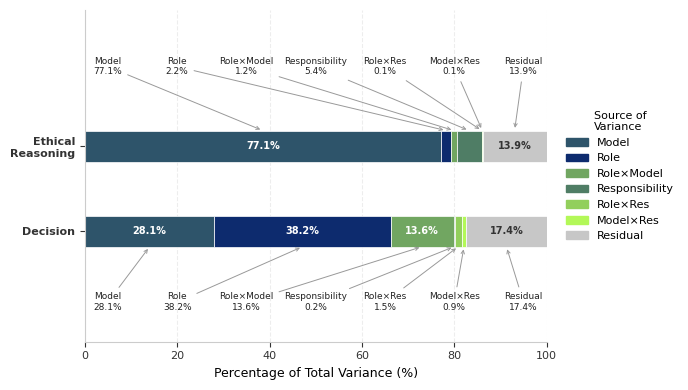

Saved → icc_variance_decomposition.png

  Model                 Decision=28.07%   Reasoning=77.13%
  Role                  Decision=38.16%   Reasoning= 2.25%
  Role×Model            Decision=13.62%   Reasoning= 1.16%
  Responsibility        Decision= 0.24%   Reasoning= 5.38%
  Role×Res              Decision= 1.55%   Reasoning= 0.11%
  Model×Res             Decision= 0.94%   Reasoning= 0.09%
  Residual              Decision=17.42%   Reasoning=13.88%


In [7]:


# ══════════════════════════════════════════════════════════════
# 0. Load data
# ══════════════════════════════════════════════════════════════
_file_list = glob.glob('*.json')
_all_data = []
for _f in _file_list:
    with open(_f, 'r', encoding='utf-8') as _fp:
        _d = json.load(_fp)
        _all_data.extend(_d if isinstance(_d, list) else [_d])
_df = pd.DataFrame(_all_data)

_RESP_COL = 'responsibility' if 'responsibility' in _df.columns else 'responsibility_name'

_MODEL_MAP = {
    'ep-20260403002353-vn2g9':    'doubao',
    'gemini-2.5-flash':           'gemini',
    'gpt-4o':                     'gpt4o',
}

def _extract_decision(text):
    if not isinstance(text, str):
        return np.nan
    m = re.search(r"DECISION:\s*(SWITCH|NO_SWITCH|NO SWITCH|STAY)", text.upper())
    if not m:
        return np.nan
    d = m.group(1).replace(" ", "_")
    return "NO_SWITCH" if d == "STAY" else d

def _extract_reasoning_words(text):
    if not isinstance(text, str):
        return np.nan
    m = re.search(r"REASONING:\s*(.*)", text, re.DOTALL | re.IGNORECASE)
    return len(m.group(1).split()) if m else np.nan

_df['decision_val'] = _df['content'].apply(
    lambda x: 1.0 if _extract_decision(x) == 'SWITCH' else
              (0.0 if _extract_decision(x) == 'NO_SWITCH' else np.nan))
_df['reasoning_words'] = _df['content'].apply(_extract_reasoning_words)
_df = _df[_df['decision_val'].notna() & _df['reasoning_words'].notna()].copy()
_df['decision_val'] = _df['decision_val'].astype(float)
_df['reasoning_words_int'] = _df['reasoning_words'].round().astype(int).clip(lower=1)

_df['model'] = _df['model'].map(_MODEL_MAP).fillna(_df['model'])

_df[_RESP_COL] = pd.Categorical(
    _df[_RESP_COL],
    categories=['neutral', 'not_responsible', 'responsible'], ordered=False)
_df['role'] = pd.Categorical(
    _df['role'],
    categories=['role_A','role_B','role_C','role_D','role_E','role_F','role_G'], ordered=False)
_df['model'] = pd.Categorical(
    _df['model'], categories=['doubao', 'gemini', 'gpt4o'], ordered=False)
print(f"Rows used: {len(_df)}  |  mean reasoning words: {_df['reasoning_words_int'].mean():.1f}")
print(f"Models: {_df['model'].cat.categories.tolist()}")

# ══════════════════════════════════════════════════════════════
# 1. Random-effect design matrices
#    Role | Res | Model×Role | Model×Res
# ══════════════════════════════════════════════════════════════
_RE_KEYS   = ['role_re', 'res_re', 'model_x_role_re', 'model_x_res_re']
_RE_LABELS = ['Role', 'Responsibility', 'Model×Role', 'Model×Res']

def _get_re(df, col):
    return pd.get_dummies(df[col], drop_first=False).astype(float)

def _get_interaction_re(df, col1, col2):
    combo = df[col1].astype(str) + '_x_' + df[col2].astype(str)
    return pd.get_dummies(combo, drop_first=False).astype(float)

def _make_re(df):
    return {
        'role_re':         _get_re(df, 'role'),
        'res_re':          _get_re(df, _RESP_COL),
        'model_x_role_re': _get_interaction_re(df, 'model', 'role'),
        'model_x_res_re':  _get_interaction_re(df, 'model', _RESP_COL),
    }

_re = _make_re(_df)
print(f"RE levels — role:{_re['role_re'].shape[1]}  res:{_re['res_re'].shape[1]}"
      f"  model×role:{_re['model_x_role_re'].shape[1]}  model×res:{_re['model_x_res_re'].shape[1]}")

# ══════════════════════════════════════════════════════════════
# 2. Fit VB models
# ══════════════════════════════════════════════════════════════
_m_dec = bmg.BinomialBayesMixedGLM.from_formula('decision_val ~ 1', _re, _df)
_r_dec = _m_dec.fit_vb()
print("\n[Decision] VB summary:")
print(_r_dec.summary())

_m_rea = bmg.PoissonBayesMixedGLM.from_formula('reasoning_words_int ~ 1', _re, _df)
_r_rea = _m_rea.fit_vb()
print("\n[Ethical Reasoning] VB summary:")
print(_r_rea.summary())

# ══════════════════════════════════════════════════════════════
# 3. Extract σ² and compute ICC with latent residual
# ══════════════════════════════════════════════════════════════
def _parse_variances(result):
    txt = result.summary().as_text()
    var = {}
    for key in _RE_KEYS:
        m = re.search(rf"{re.escape(key)}\s+V\s+([-\d.]+)\s+[\d.]+", txt)
        var[key] = np.exp(2 * float(m.group(1))) if m else np.nan
    return var

_var_dec = _parse_variances(_r_dec)
_var_rea = _parse_variances(_r_rea)

_RESID_DEC = np.pi**2 / 3
_RESID_REA = np.log(1 + 1 / _df['reasoning_words_int'].mean())

def _to_icc(var_dict, residual_var):
    total = sum(v for v in var_dict.values() if not np.isnan(v)) + residual_var
    result = {k: (v / total * 100 if not np.isnan(v) else 0.0) for k, v in var_dict.items()}
    result['residual'] = residual_var / total * 100
    return result

_icc_dec = _to_icc(_var_dec, _RESID_DEC)
_icc_rea = _to_icc(_var_rea, _RESID_REA)
print("\nDecision ICC (%):", {k: round(v,2) for k,v in _icc_dec.items()})
print("Reasoning ICC (%):", {k: round(v,2) for k,v in _icc_rea.items()})

# ══════════════════════════════════════════════════════════════
# 4. Ordering: by avg ICC, residual always last
# ══════════════════════════════════════════════════════════════
_avg_icc = {k: (_icc_dec[k] + _icc_rea[k]) / 2 for k in _RE_KEYS}
_order = sorted(_RE_KEYS, key=lambda k: _avg_icc[k], reverse=True) + ['residual']

_COLOR_HIGH = np.array([0x0d, 0x2b, 0x6e]) / 255
_COLOR_LOW  = np.array([0xb3, 0xf8, 0x58]) / 255
_seg_colors = {
    _RE_KEYS[i]: tuple(_COLOR_HIGH + (_COLOR_LOW - _COLOR_HIGH) * i / (len(_RE_KEYS) - 1))
    for i in range(len(_RE_KEYS))
}
_seg_colors['residual'] = (0.78, 0.78, 0.78)

# ══════════════════════════════════════════════════════════════
# 5. Plot
# ══════════════════════════════════════════════════════════════
_OUTCOMES = ['Decision', 'Ethical\nReasoning']
_ICC_BARS = [_icc_dec, _icc_rea]
_BAR_H    = round(0.52 * 0.70, 3)

_ALL_KEYS   = _RE_KEYS + ['residual']
_ALL_LBLS   = _RE_LABELS + ['Residual']
_ANN_KEYS   = _order
_ANN_LABELS = dict(zip(_ALL_KEYS, _ALL_LBLS))

fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

_seg_cx = {}
for yi, icc in enumerate(_ICC_BARS):
    left = 0.0
    for key in _order:
        pct   = icc[key]
        color = _seg_colors[key]
        ax.barh(yi, pct, left=left, height=_BAR_H,
                color=color, edgecolor='white', linewidth=0.5)
        if pct >= 8.0:
            txt_color = '#333333' if key == 'residual' else 'white'
            ax.text(left + pct / 2, yi, f'{pct:.1f}%',
                    ha='center', va='center', fontsize=7,
                    fontweight='bold', color=txt_color)
        _seg_cx[(yi, key)] = left + pct / 2
        left += pct


_half_h = _BAR_H / 2
_ann_cfg = [
    (0, -0.72, 'top'),  
    (1,  1.82, 'bottom'),
]

for (yi, text_y, va) in _ann_cfg:
    icc      = _ICC_BARS[yi]

    segs_lr  = sorted(_ANN_KEYS, key=lambda k: _seg_cx[(yi, k)])
    n        = len(segs_lr)

    text_xs  = np.linspace(5, 95, n)
    bar_edge = yi - _half_h if text_y < yi else yi + _half_h

    for i, key in enumerate(segs_lr):
        cx  = _seg_cx[(yi, key)]
        pct = icc[key]
        lbl = _ANN_LABELS[key]
        ax.annotate(
            f'{lbl}\n{pct:.1f}%',
            xy=(cx, bar_edge),
            xytext=(text_xs[i], text_y),
            ha='center', va=va,
            fontsize=6.5, color='#222222',
            arrowprops=dict(arrowstyle='->', color='#999999',
                            lw=0.7, mutation_scale=6),
        )

ax.set_xlim(0, 100)
ax.set_ylim(-1.3, 2.6)
ax.set_yticks([0, 1])
ax.set_yticklabels(_OUTCOMES, fontsize=10, fontweight='bold')
ax.set_xlabel('Percentage of Total Variance (%)', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')
ax.xaxis.grid(True, linestyle='--', alpha=0.35, color='#cccccc')
ax.set_axisbelow(True)
ax.tick_params(axis='both', colors='#333333', labelsize=8)

_legend_handles = [
    mpatches.Patch(color=_seg_colors[k], label=_ANN_LABELS[k])
    for k in _order
]
ax.legend(handles=_legend_handles,
          loc='center left', bbox_to_anchor=(1.02, 0.5),
          ncol=1, fontsize=8, frameon=False,
          title='Source of\nVariance', title_fontsize=8)

plt.tight_layout()
plt.savefig('icc_variance_decomposition.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved → icc_variance_decomposition.png')
print()
for k in _order:
    print(f"  {_ANN_LABELS[k]:<20s}  Decision={_icc_dec[k]:5.2f}%   Reasoning={_icc_rea[k]:5.2f}%")

In [ ]:
import numpy as np
import re
import pandas as pd

# ══════════════════════════════════════════════════════════════
# ICC 95% CI via Monte Carlo from VB posterior
# 4 components: Role / Res / Model×Role / Model×Res
# ══════════════════════════════════════════════════════════════

N_MC = 50_000
RNG  = np.random.default_rng(0)

_RE_KEYS_   = ['role_re', 'res_re', 'model_x_role_re', 'model_x_res_re']
_RE_LABELS_ = ['Role', 'Responsibility', 'Model×Role', 'Model×Res']

def _parse_vb_vcp(result):
    txt = result.summary().as_text()
    mus, sigmas = {}, {}
    for key in _RE_KEYS_:
        m = re.search(rf"{re.escape(key)}\s+V\s+([-\d.]+)\s+([\d.]+)", txt)
        if m:
            mus[key]    = float(m.group(1))
            sigmas[key] = float(m.group(2))
        else:
            mus[key] = sigmas[key] = np.nan
    return mus, sigmas

_mus_dec, _sigs_dec = _parse_vb_vcp(_r_dec)
_mus_rea, _sigs_rea = _parse_vb_vcp(_r_rea)

def _mc_icc(mus, sigmas, residual_var, n=N_MC):
    keys      = [k for k in _RE_KEYS_ if not np.isnan(mus.get(k, np.nan))]
    log_sds   = np.column_stack([RNG.normal(mus[k], sigmas[k], size=n) for k in keys])
    vars_mc   = np.exp(2 * log_sds)               # (n, K)
    total     = vars_mc.sum(axis=1) + residual_var # (n,)
    icc_mc    = vars_mc / total[:, None] * 100     # (n, K)
    resid_pct = residual_var / total * 100          # (n,)

    rows = []
    for i, k in enumerate(keys):
        lbl = _RE_LABELS_[_RE_KEYS_.index(k)]
        rows.append({'Source':   lbl,
                     'Median %': round(float(np.median(icc_mc[:, i])), 2),
                     'Mean %':   round(float(icc_mc[:, i].mean()), 2),
                     'CI 2.5%':  round(float(np.percentile(icc_mc[:, i],  2.5)), 2),
                     'CI 97.5%': round(float(np.percentile(icc_mc[:, i], 97.5)), 2)})
    rows.append({'Source':   'Residual',
                 'Median %': round(float(np.median(resid_pct)), 2),
                 'Mean %':   round(float(resid_pct.mean()), 2),
                 'CI 2.5%':  round(float(np.percentile(resid_pct,  2.5)), 2),
                 'CI 97.5%': round(float(np.percentile(resid_pct, 97.5)), 2)})
    return pd.DataFrame(rows).set_index('Source')

_RESID_DEC = np.pi**2 / 3
_RESID_REA = np.log(1 + 1 / _df['reasoning_words_int'].mean())

print("━" * 62)
print(f"  Decision  — ICC with latent residual (π²/3 ≈ {_RESID_DEC:.2f})")
print("━" * 62)
print(_mc_icc(_mus_dec, _sigs_dec, _RESID_DEC).to_string())

print()
print("━" * 62)
print(f"  Ethical Reasoning  — ICC with Poisson residual (≈ {_RESID_REA:.4f})")
print("━" * 62)
print(_mc_icc(_mus_rea, _sigs_rea, _RESID_REA).to_string())